In [ ]:
import numpy as np 
import scipy 
import matplotlib.pyplot as plt
from data import *
from optimization import *
import torch
rng = np.random.default_rng(seed=0)

In [52]:
# well-posed params 
c1, lambda1, lambda2 = torch.Tensor([0.4]), torch.Tensor([0.005]), torch.Tensor([0.01])
t = torch.linspace(0.0, 100, 32)
clean_signal, noisy_signal = make_synthetic_observation_three_param(c1, lambda1, lambda2, t, 0.05, rng=rng)
print(f'{torch.sum(clean_signal - noisy_signal):.4f}')

TypeError: make_synthetic_observation_three_param() got an unexpected keyword argument 'rng'

In [47]:
for _ in range(10):
    print(f"{rng.random(3)}")

[0.05212133 0.22270312 0.08331929]
[0.15063125 0.12491989 0.37329888]
[0.23817385 0.00440887 0.03291212]
[0.99005362 0.24514448 0.0408276 ]
[0.62600979 0.55164105 0.38885152]
[0.73333183 0.9369829  0.39635525]
[0.37532583 0.51418335 0.2344761 ]
[0.17397391 0.38868102 0.67701903]
[0.01477    0.13839525 0.80810812]
[0.33214529 0.55915591 0.05549369]


In [48]:
# now recover: compile over many inits 
solutions = []
clean_signals = []
from tqdm import tqdm
for _ in tqdm(range(100), desc='Running Direct NLLS with different inits'):
    x_init = rng.random(3)
    clean_signal, noisy_signal = make_synthetic_observation_three_param(c1, lambda1, lambda2, t, 0.05)
    print(f'Initial guess: {x_init}, clean-noisy sum: {torch.sum(clean_signal - noisy_signal):.4f}')
    result = solve_direct_nlls(noisy_signal, t, x_init=x_init)
    solutions.append(result['x_hat'])
    clean_signal_recovered, _ = make_synthetic_observation_three_param(result['x_hat'][0], result['x_hat'][1], result['x_hat'][2], t, 0.0)
    clean_signals.append(clean_signal_recovered)

Running Direct NLLS with different inits:  22%|██▏       | 22/100 [00:00<00:00, 216.12it/s]

Initial guess: [0.55077351 0.02773809 0.20725844], clean-noisy sum: -0.1726
Initial guess: [0.4478968  0.5238123  0.12530839], clean-noisy sum: 0.2681
Initial guess: [0.4590367  0.7804835  0.70578742], clean-noisy sum: 0.1131
Initial guess: [0.36907964 0.49614468 0.79900279], clean-noisy sum: -0.0965
Initial guess: [0.26317606 0.14022048 0.96900722], clean-noisy sum: 0.0689
Initial guess: [0.87300735 0.87418785 0.47717226], clean-noisy sum: 0.1322
Initial guess: [0.03535209 0.74296351 0.79015786], clean-noisy sum: 0.0761
Initial guess: [0.96513079 0.03578056 0.81281166], clean-noisy sum: -0.0462
Initial guess: [0.33679812 0.66658971 0.9005603 ], clean-noisy sum: -0.2921
Initial guess: [0.2516181  0.99342822 0.03784869], clean-noisy sum: 0.1900
Initial guess: [0.11471559 0.48067774 0.71895082], clean-noisy sum: 0.2272
Initial guess: [0.92649393 0.84727145 0.97051334], clean-noisy sum: 0.1892
Initial guess: [0.44135864 0.40631539 0.58945009], clean-noisy sum: -0.1382
Initial guess: [0.69

Running Direct NLLS with different inits:  79%|███████▉  | 79/100 [00:00<00:00, 241.46it/s]

Initial guess: [0.78744251 0.07025206 0.31929649], clean-noisy sum: -0.2725
Initial guess: [0.3791795  0.89943138 0.64633608], clean-noisy sum: 0.0812
Initial guess: [0.404751   0.92200876 0.68713121], clean-noisy sum: -0.3087
Initial guess: [0.67224647 0.71209328 0.54182789], clean-noisy sum: 0.6502
Initial guess: [0.46749853 0.97249162 0.57182702], clean-noisy sum: -0.2419
Initial guess: [0.40619763 0.09357603 0.19225935], clean-noisy sum: -0.1079
Initial guess: [0.98328958 0.96170458 0.00297614], clean-noisy sum: 0.1963
Initial guess: [0.07779515 0.67889046 0.21801662], clean-noisy sum: -0.1534
Initial guess: [0.66365302 0.209822   0.39684265], clean-noisy sum: 0.0006
Initial guess: [0.32588619 0.24648365 0.77511442], clean-noisy sum: 0.0414
Initial guess: [0.30381383 0.91465515 0.18872081], clean-noisy sum: -0.2073
Initial guess: [0.89493611 0.15348855 0.29594453], clean-noisy sum: -0.1397
Initial guess: [0.98370294 0.04731794 0.83829449], clean-noisy sum: -0.0619
Initial guess: [0

Running Direct NLLS with different inits: 100%|██████████| 100/100 [00:00<00:00, 243.72it/s]


In [49]:
solutions

[array([0.99998677, 0.00790379, 0.00790383]),
 array([0.8499938, 0.0079801, 0.0079801]),
 array([0.87511561, 0.00782034, 0.00782034]),
 array([0.44772956, 0.004     , 0.01172964]),
 array([0.23275344, 0.004     , 0.00944914]),
 array([0.99392945, 0.00803859, 0.00803859]),
 array([0.64577497, 0.004     , 0.01928215]),
 array([0.56754557, 0.004     , 0.01489212]),
 array([0.9999796 , 0.00770459, 0.00770462]),
 array([0.78322478, 0.0079824 , 0.0079824 ]),
 array([0.6876089 , 0.00667547, 0.01130629]),
 array([0.7822399 , 0.00463223, 0.03602801]),
 array([0.89393583, 0.00622559, 0.0309631 ]),
 array([0.91724952, 0.00796027, 0.00796027]),
 array([0.99999909, 0.00814804, 0.00814804]),
 array([0.93699151, 0.00667279, 0.05      ]),
 array([0.97541747, 0.00768745, 0.00768745]),
 array([0.90342679, 0.00689772, 0.02625986]),
 array([0.99999949, 0.00785001, 0.00785011]),
 array([0.99992835, 0.00779729, 0.00779863]),
 array([0.85065516, 0.00818366, 0.00818367]),
 array([0.61981908, 0.004     , 0.017

Text(0, 0.5, 'Signal')

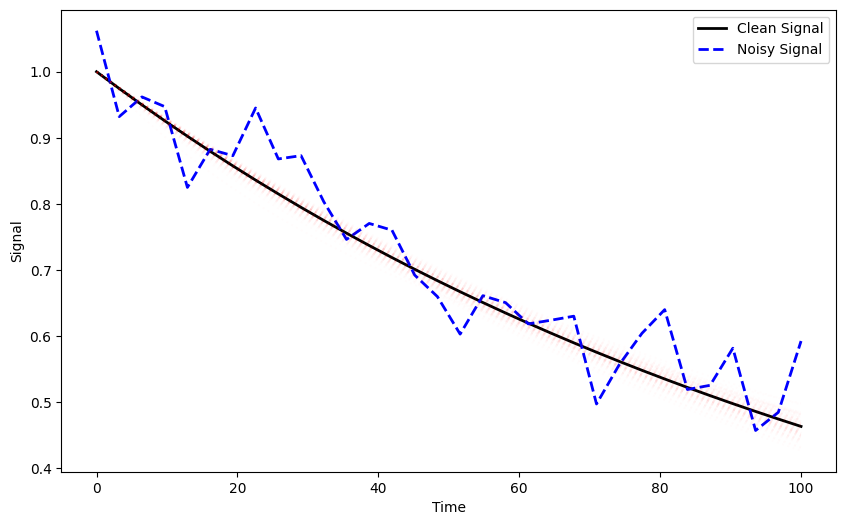

In [50]:
# visualize all of the curves on top of each other
fig = plt.figure(figsize=(10, 6))
plt.plot(t, clean_signal, label='Clean Signal', linewidth=2, color='black')
plt.plot(t, noisy_signal, label='Noisy Signal', linestyle='dashed', linewidth=2, color='blue')
for clean_signal_recovered in clean_signals:
    plt.plot(t, clean_signal_recovered, linestyle='dotted', alpha=0.01, color='red')
plt.legend()
plt.xlabel('Time')
plt.ylabel('Signal')

In [51]:
solutions = np.array(solutions)
true_solution = np.array([c1.item(), lambda1.item(), lambda2.item()])
rel_errors = np.linalg.norm(solutions - true_solution, axis=1) / np.linalg.norm(true_solution)
rel_rmse = np.sqrt(np.mean(rel_errors ** 2))
print(f'Relative RMSE of recovered parameters: {rel_rmse:.4f}')

Relative RMSE of recovered parameters: 1.2076
